# Decision Trees and Random Forests

This page covers two closely related supervised models: the interpretable
**decision tree**, and the **random forest** ensemble that combines many trees
for accuracy and robustness. Both handle classification *and* regression.

## Growing a decision tree

A decision tree recursively **partitions the feature space**. At each node it
picks a feature and a threshold, sending samples left or right depending on
whether the feature is above or below it. The goal at every split is to make the
resulting groups as **pure** as possible — ideally each leaf contains one class.

Purity is measured by the **Gini impurity** of a node with class fractions
$p_k$:

$$G = 1 - \sum_{k} p_k^2$$

$G = 0$ is a perfectly pure node. The **CART** (Classification And Regression
Trees) algorithm greedily chooses the split that most reduces impurity — for
regression it minimizes MSE within each group instead.

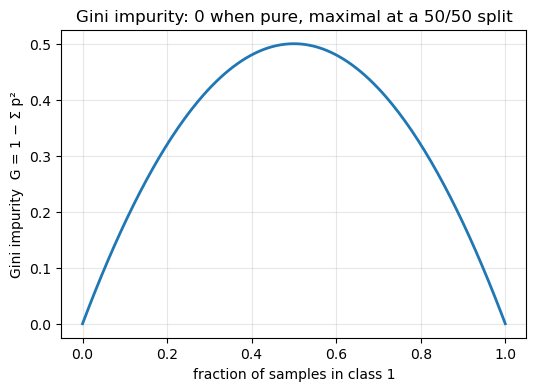

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Gini impurity for a two-class node as the class balance varies
p = np.linspace(0, 1, 200)
gini = 1 - (p**2 + (1 - p)**2)
plt.figure(figsize=(6, 4))
plt.plot(p, gini, lw=2)
plt.xlabel("fraction of samples in class 1")
plt.ylabel("Gini impurity  G = 1 − Σ p²")
plt.title("Gini impurity: 0 when pure, maximal at a 50/50 split")
plt.grid(alpha=0.3)
plt.show()

### Training and reading a tree

Because every split is a simple threshold, a trained tree is a flowchart you can
read top to bottom — this transparency is a big part of why trees are popular in
science. Here is a shallow tree on the Iris data set.

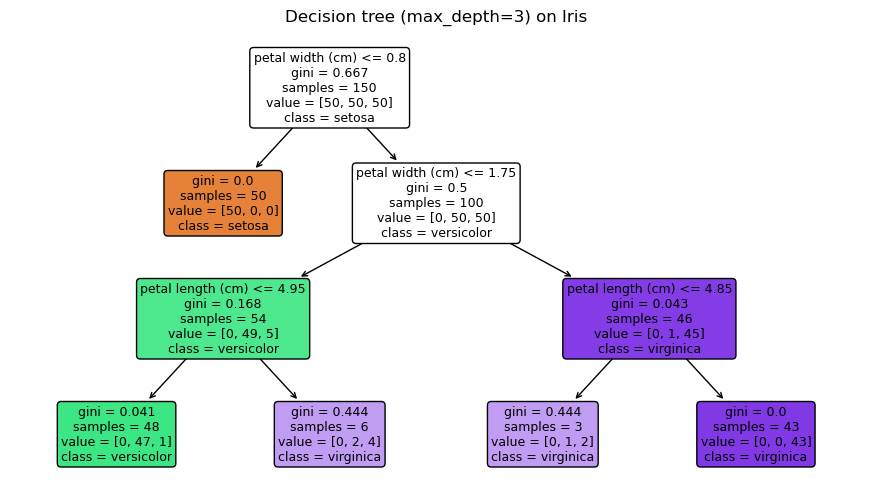

In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree

iris = load_iris()
X, y = iris.data, iris.target
tree = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X, y)

plt.figure(figsize=(11, 6))
plot_tree(tree, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=9)
plt.title("Decision tree (max_depth=3) on Iris")
plt.show()

The splits carve the feature space into **axis-aligned rectangles**. Plotting
the decision regions for two features makes the boxy boundaries obvious — quite
different from the smooth linear boundary of logistic regression.

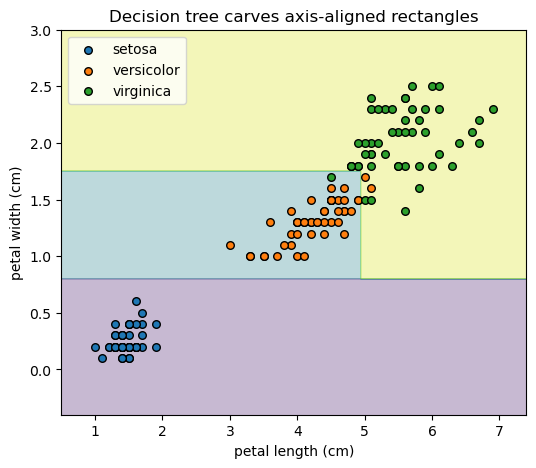

In [3]:
X2 = iris.data[:, 2:4]      # petal length, petal width
t2 = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X2, y)

xx, yy = np.meshgrid(np.linspace(X2[:, 0].min()-0.5, X2[:, 0].max()+0.5, 300),
                     np.linspace(X2[:, 1].min()-0.5, X2[:, 1].max()+0.5, 300))
Z = t2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
for k, name in enumerate(iris.target_names):
    plt.scatter(X2[y == k, 0], X2[y == k, 1], label=name, edgecolor="k", s=30)
plt.xlabel("petal length (cm)"); plt.ylabel("petal width (cm)")
plt.title("Decision tree carves axis-aligned rectangles")
plt.legend()
plt.show()

### Regularization and overfitting

Left unchecked, a tree keeps splitting until every leaf is pure — memorizing the
training data. Key hyperparameters control complexity:
`max_depth`, `min_samples_split`, `min_samples_leaf`, `max_leaf_nodes`,
`max_features`. **Pruning** can also remove low-value branches after training.

The plot below shows train vs. test accuracy as the tree deepens: training
accuracy climbs to 1.0 while test accuracy peaks then sags — the classic
overfitting signature.

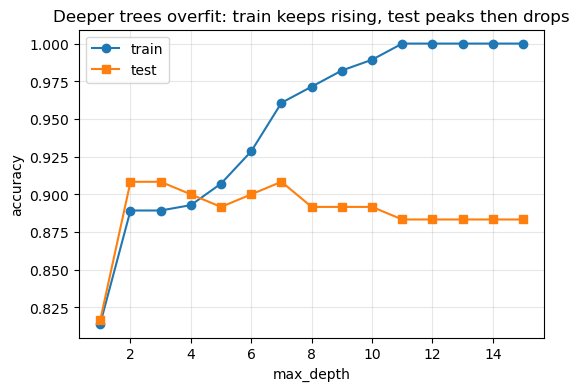

In [4]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

Xm, ym = make_moons(n_samples=400, noise=0.3, random_state=0)
Xtr, Xte, ytr, yte = train_test_split(Xm, ym, test_size=0.3, random_state=0)

depths = range(1, 16)
tr = [DecisionTreeClassifier(max_depth=d, random_state=0).fit(Xtr, ytr).score(Xtr, ytr) for d in depths]
te = [DecisionTreeClassifier(max_depth=d, random_state=0).fit(Xtr, ytr).score(Xte, yte) for d in depths]

plt.figure(figsize=(6, 4))
plt.plot(depths, tr, "o-", label="train")
plt.plot(depths, te, "s-", label="test")
plt.xlabel("max_depth"); plt.ylabel("accuracy")
plt.title("Deeper trees overfit: train keeps rising, test peaks then drops")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Advantages and limitations of decision trees

**Advantages**
- Simple to understand; every decision path can be traced and explained.
- Implicitly performs feature selection (ignores redundant variables).
- Handles numerical *and* categorical features; robust to outliers.

**Limitations**
- Prone to **overfitting** and **high variance** — small data changes can
  reshape the tree.
- Large trees become hard to interpret.
- Inference is fast, but *training* is the expensive part: growing the tree
  scales roughly as $O(m \cdot N \log N)$.

## Random forests

A **random forest** is an *ensemble* of decision trees. Each tree is trained on
a random subset of the data (and a random subset of features at each split), and
their predictions are combined. Diversity among the trees is the key: if the
trees make *different* errors, averaging them cancels the noise, reducing
variance and overfitting.

**How the samples are drawn:**
- **Bagging** = bootstrap sampling *with* replacement.
- **Pasting** = sampling *without* replacement.

**How the votes are combined:**
- **Hard voting** — each tree votes for one class; the majority wins.
- **Soft voting** — average the predicted class probabilities, then pick the
  highest. Usually preferred because it accounts for each tree's confidence.

The forest's decision boundary is noticeably **smoother** than a single tree's.

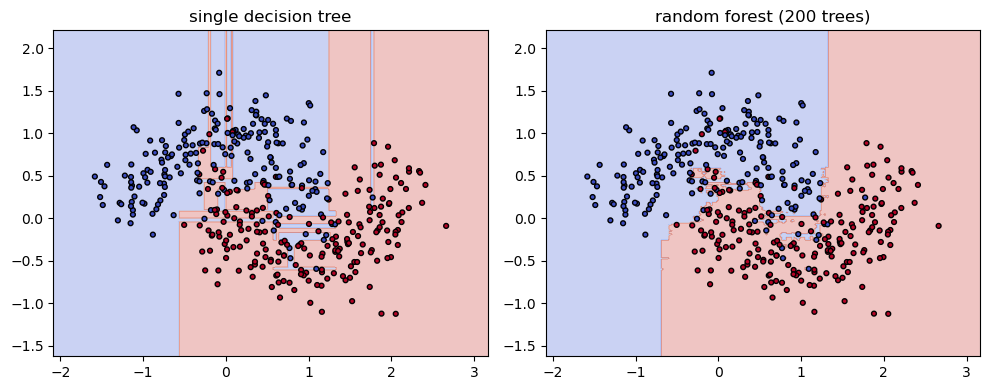

In [5]:
from sklearn.ensemble import RandomForestClassifier

single = DecisionTreeClassifier(max_depth=None, random_state=0).fit(Xm, ym)
forest = RandomForestClassifier(n_estimators=200, random_state=0).fit(Xm, ym)

xx, yy = np.meshgrid(np.linspace(Xm[:, 0].min()-0.5, Xm[:, 0].max()+0.5, 300),
                     np.linspace(Xm[:, 1].min()-0.5, Xm[:, 1].max()+0.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

plt.figure(figsize=(10, 4))
for i, (name, m) in enumerate([("single decision tree", single),
                               ("random forest (200 trees)", forest)]):
    Z = m.predict(grid).reshape(xx.shape)
    plt.subplot(1, 2, i + 1)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap="coolwarm", edgecolor="k", s=12)
    plt.title(name)
plt.tight_layout()
plt.show()

### Why (and why not) use a random forest?

**Pros** — usually more accurate than a single tree; more representation power;
smoother, more robust predictions; provides **probabilistic** predictions and
**uncertainty quantification** through the spread across trees.

**Cons** — computationally more expensive (scales with the number of trees);
less interpretable than one tree; can increase bias when each tree sees only a
small subset.

## Feature importance

Random forests can report **feature importance** — how much each feature reduces
Gini impurity on average across all trees and splits. This is a route toward
*interpretable* models: it tells you which variables actually drive the
predictions.

In environmental science this helps decide which (possibly expensive to measure)
features to collect, which pollutants or drivers matter most, and how to trim a
model down to its most informative inputs.

:::{note}
Impurity-based importance is fast but biased toward high-cardinality and
continuous features. When importances drive scientific conclusions, cross-check
with **permutation importance** (`sklearn.inspection.permutation_importance`),
which measures how much the score drops when a single feature is shuffled.
:::

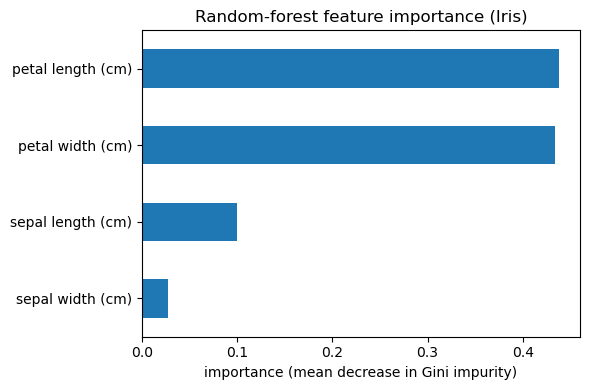

sepal width (cm)     0.028
sepal length (cm)    0.100
petal width (cm)     0.434
petal length (cm)    0.438
dtype: float64


In [6]:
import pandas as pd

rf = RandomForestClassifier(n_estimators=300, random_state=0).fit(iris.data, iris.target)
imp = pd.Series(rf.feature_importances_, index=iris.feature_names).sort_values()

plt.figure(figsize=(6, 4))
imp.plot.barh()
plt.xlabel("importance (mean decrease in Gini impurity)")
plt.title("Random-forest feature importance (Iris)")
plt.tight_layout()
plt.show()
print(imp.round(3))

## Beyond bagging: boosting and stacking

Random forests build trees **in parallel**. Two other ensemble ideas came up in
lecture:

- **Boosting** — train weak learners **sequentially**, each correcting its
  predecessor. *AdaBoost* up-weights misclassified samples; *gradient boosting*
  fits each new tree to the residuals of the previous ones.
- **Stacking / blending** — train a final "meta" model to combine the
  predictions of several different base models, learning *when* to trust each
  one.

## Summary

This page covered **decision trees** and the **ensemble methods** built on top
of them — a family of models that drop the straight-line assumption and instead
partition the feature space into regions.

- A **decision tree** repeatedly splits the data on one feature at a time,
  choosing the split that most reduces **Gini impurity** (the CART algorithm).
  The result is a set of axis-aligned regions, each assigned a class (or a mean,
  for regression).
- Trees are **highly interpretable** — you can read the decision path as a
  sequence of if/then rules — and need little data preprocessing (no scaling
  required). But a single deep tree **overfits** and has **high variance**:
  small changes in the data can produce a very different tree.
- **Random forests** tame that variance by averaging **many diverse trees**.
  Two sources of diversity make this work:
  - **Bagging** — each tree is trained on a bootstrap sample (random draw with
    replacement) of the training data.
  - **Random feature subsets** — at each split, only a random subset of features
    is considered.
  Averaging (or majority **voting** for classification) over these decorrelated
  trees gives smoother, more accurate, and probabilistic predictions than any
  single tree.
- **Feature importance** from a forest ranks which variables drive the
  predictions — a practical tool for interpretable environmental modeling. Keep
  in mind that the default impurity-based importance is biased toward
  high-cardinality features; **permutation importance** is a more reliable
  alternative.
- Beyond bagging, **boosting** (train weak trees sequentially, each correcting
  its predecessor) and **stacking** (learn a meta-model to combine several base
  models) are two other ways to build strong ensembles from simple trees.

Next: [Tutorial on Random Forests (Wildfire cause prediction)](randomforests.ipynb),
which applies a random forest end-to-end to a real environmental data set.